## Building the chatbot with multiple tools using LANGGRAPH

In [1]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper

/var/folders/rc/76flhrzn4pgf33r81dt4lky00000gn/T/ipykernel_2572/4084895585.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun


In [2]:
api_arxiv_wrapper=ArxivAPIWrapper(top_k_results=2)
arxiv=ArxivQueryRun(api_wrapper=api_arxiv_wrapper)
print(arxiv.name)

arxiv_tool = ArxivQueryRun(
    api_wrapper=ArxivAPIWrapper()
)

arxiv


In [3]:
import arxiv

search = arxiv.Search(
    query="Attention is all you need",
    max_results=1
)

try:
    paper = next(search.results())
    print(paper.title)
except Exception as e:
    print(type(e), e)

<class 'arxiv.arxiv.HTTPError'> Page request resulted in HTTP 301: None (http://export.arxiv.org/api/query?search_query=Attention+is+all+you+need&id_list=&sortBy=relevance&sortOrder=descending&start=0&max_results=1)


In [4]:
api_wiki_wrapper=WikipediaAPIWrapper(top_k_results=2)
wiki=WikipediaQueryRun(api_wrapper=api_wiki_wrapper)
wiki.name

'wikipedia'

In [5]:
wiki.invoke("what is machine learning")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from  data and generalize to unseen data, and thus perform tasks without being explicitly programmed. Advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\nStatistics and mathematical optimisation methods compose the foundations of machine learning. Data mining is a related field of study, focusing on exploratory data analysis (EDA) through unsupervised learning.\nFrom a theoretical viewpoint, probably approximately correct learning provides a mathematical and statistical framework for describing machine learning. Most traditional machine learning and deep learning algorithms can be described as empirical risk minimisation under this framework.\n\n\n\nPage: Grokking (machine learning)\n

In [6]:
from dotenv import load_dotenv
load_dotenv()

import os
os.environ['TAVILY_API_KEY']=os.getenv('TAVILY_API_KEY')
os.environ['GROQ_API_KEY']=os.getenv('GROQ_API_KEY')

In [7]:
from langchain_community.tools.tavily_search import TavilySearchResults

tavily=TavilySearchResults()

/var/folders/rc/76flhrzn4pgf33r81dt4lky00000gn/T/ipykernel_2572/3880125110.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily=TavilySearchResults()


In [8]:
tavily.invoke('provide me the recent AI news for july 15th 2026')

[{'title': 'Daily AI & Data News Summary – 15 July 2026 : r/DecodingDataSciAI',
  'url': 'https://www.reddit.com/r/DecodingDataSciAI/comments/1uwwv0i/daily_ai_data_news_summary_15_july_2026',
  'content': "🔹 DeepMind CEO calls for an independent global AI safety body Google DeepMind CEO Demis Hassabis has urged governments to establish an independent international organization to evaluate frontier AI models before deployment. The proposal reflects growing concern that AI capabilities are advancing faster than global governance frameworks.\n\n🔹 OpenAI researcher reportedly launches $2B AI drug discovery startup OpenAI researcher Miles Wang is reportedly in talks to launch a new AI-powered drug discovery startup targeting a valuation of around $2 billion. The move highlights the growing use of frontier AI in life sciences and pharmaceutical research. [...] 🔹 OpenAI's first AI hardware device reportedly takes shape Reports suggest OpenAI's first hardware product will be a screenless AI co

In [9]:
# combine all the tools in the list

tools=[tavily, wiki, arxiv_tool]

In [10]:
from langchain_groq import ChatGroq

llm=ChatGroq(model='llama-3.1-8b-instant')
llm_tools=llm.bind_tools(tools)

In [11]:
from pprint import pprint

from langchain_core.messages import AIMessage, HumanMessage

llm_tools.invoke([HumanMessage(content=f"What is the recent AI news")])

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'y9mszqf93', 'function': {'arguments': '{"query":"recent AI news"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 553, 'total_tokens': 573, 'completion_time': 0.033403827, 'completion_tokens_details': None, 'prompt_time': 0.040404804, 'prompt_tokens_details': None, 'queue_time': 0.050184195, 'total_time': 0.073808631}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f6be7-8e5d-7361-a46a-0a7f7b9f81cc-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'recent AI news'}, 'id': 'y9mszqf93', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 553, 'output_tokens': 20, 'total_tokens': 573})

In [12]:
llm_tools.invoke([HumanMessage(content=f"What is the recent AI news")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'Recent AI news'},
  'id': 'jhjxc3zsg',
  'type': 'tool_call'}]

In [13]:
# State Schema

from typing import Annotated
from  typing_extensions import TypedDict

from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [14]:
# Entire Chatbot using langgraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

from langgraph.prebuilt import ToolNode, tools_condition


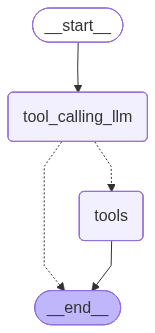

In [15]:
# Node Definition

def tool_calling_llm(state: State):
    return {'messages': [llm_tools.invoke(state['messages'])]}

builder=StateGraph(State)

builder.add_node('tool_calling_llm', tool_calling_llm)
builder.add_node('tools', ToolNode(tools))

builder.add_edge(START, 'tool_calling_llm')
builder.add_conditional_edges(
    'tool_calling_llm',
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tool
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge('tools', END)

graph_builder=builder.compile()
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [16]:
from pprint import pprint

messages=graph_builder.invoke({'messages': HumanMessage(content='Attention is all you need')})
for message in messages['messages']:
    message.pretty_print()

================================ Human Message =================================

Attention is all you need
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (v3s5dxbqt)
 Call ID: v3s5dxbqt
  Args:
    query: Attention is all you need paper
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Attention Is All You Need", "url": "https://en.wikipedia.org/wiki/Attention_Is_All_You_Need", "content": "\"Attention Is All You Need\" is a 2017 research paper in machine learning authored by eight scientists and engineers working at Google. The paper introduced a new deep learning architecture known as the transformer \"Transformer (deep learning)\"), based on the attention mechanism proposed in 2014 by Bahdanau et al. The transformer approach it describes has become the main architecture of a wide variety of artificial intelligence systems, including 

In [17]:
from pprint import pprint

messages=graph_builder.invoke({'messages': HumanMessage(content='what is machine learning?')})
for message in messages['messages']:
    message.pretty_print()

================================ Human Message =================================

what is machine learning?
================================== Ai Message ==================================
Tool Calls:
  wikipedia (j387p60hn)
 Call ID: j387p60hn
  Args:
    query: machine learning
================================= Tool Message =================================
Name: wikipedia

Page: Machine learning
Summary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from  data and generalize to unseen data, and thus perform tasks without being explicitly programmed. Advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.
Statistics and mathematical optimisation methods compose the foundations of machine learning. Data mining is a related field of study, focusing on exploratory data